# Week 3 Project


In [50]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage import data

plt.gray()

<Figure size 640x480 with 0 Axes>

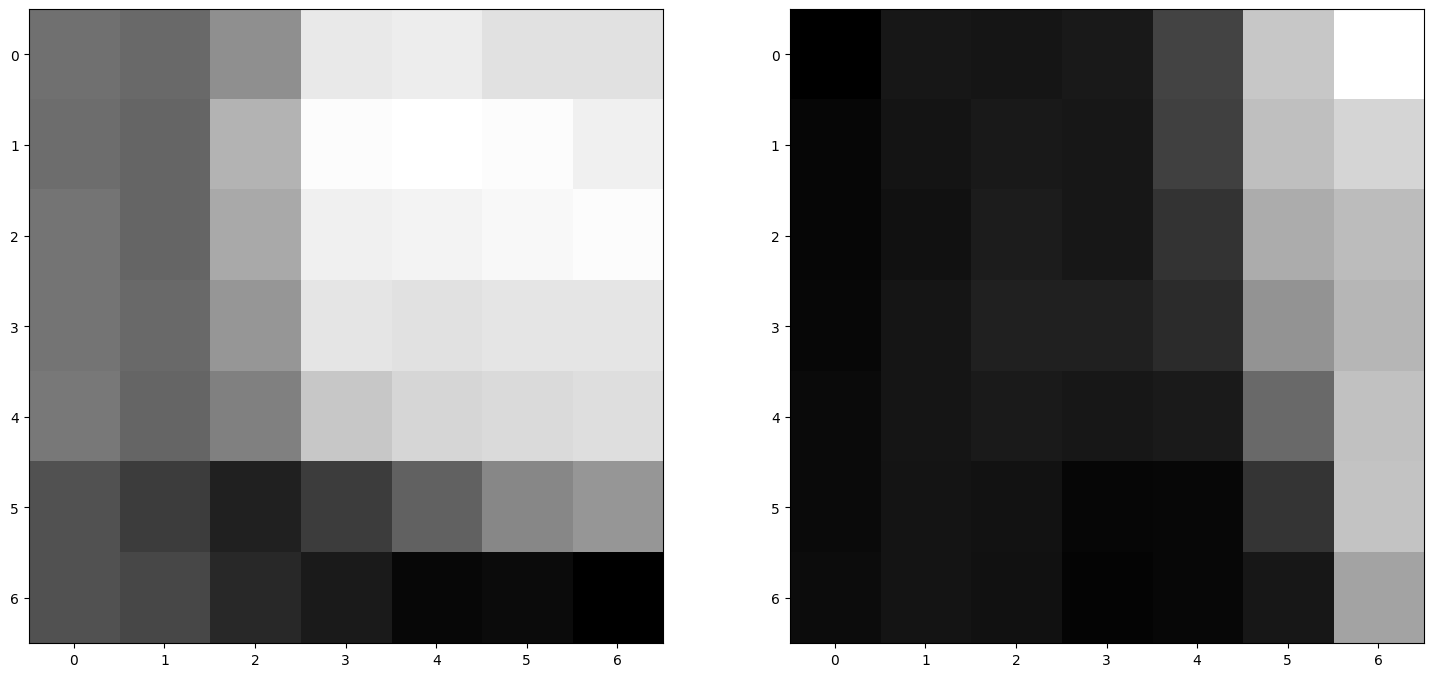

In [51]:
img_left = cv2.imread("nose_left.png")
img_right = cv2.imread("nose_right.png")

# Rescale images (can be left out).
#img_size = (int(img_left.shape[1]/5), int(img_left.shape[0]/5))
#img_left = cv2.resize(img_left, img_size, interpolation=cv2.INTER_AREA)
#img_right = cv2.resize(img_right, img_size, interpolation=cv2.INTER_AREA)

# Convert images to grayscale
template = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)


f, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(18,18))
ax_left.imshow(template, cmap='gray')
ax_right.imshow(gray_right, cmap='gray')


#STEP 1

In [52]:
def calc_sad(img_1, img_2):
    # Convert to int of 32 bits (int32) in order to avoid overflow
    img_l = np.asarray(img_1, dtype=np.int32)
    img_r = np.asarray(img_2, dtype=np.int32)
    
    sad = np.sum(np.abs(img_l - img_r))
    
    return sad

SAD = calc_sad(template, gray_right)
print(f"El valor SAD es: {SAD}")

El valor SAD es: 7657


#STEP 2

In [53]:
img_nose_1 = cv2.imread("nose1.png")
gray_nose_1 = cv2.cvtColor(img_nose_1, cv2.COLOR_BGR2GRAY)
SAD_nose_1 = calc_sad(template, gray_nose_1)

img_nose_2 = cv2.imread("nose2.png")
gray_nose_2 = cv2.cvtColor(img_nose_2, cv2.COLOR_BGR2GRAY)
SAD_nose_2 = calc_sad(template, gray_nose_2)

img_nose_3 = cv2.imread("nose3.png")
gray_nose_3 = cv2.cvtColor(img_nose_3, cv2.COLOR_BGR2GRAY)
SAD_nose_3 = calc_sad(template, gray_nose_3)
SAD_nose_1 = calc_sad(template, gray_nose_1)

all_SADs = [SAD_nose_1, SAD_nose_2, SAD_nose_3]
best_match=all_SADs[0]
best_index = 0

for i, current_sad in enumerate(all_SADs):
    if current_sad < best_match:
        best_match = current_sad
        best_index = i

print(f"The best SAD is {best_match} and corresponds to the image {best_index + 1}")


The best SAD is 119 and corresponds to the image 2


#STEP 3

In [54]:
img_span = cv2.imread("nose_span.png")
gray_span = cv2.cvtColor(img_span, cv2.COLOR_BGR2GRAY)

def find(template, span):
    wide_template = template.shape[1]
    wide_span = span.shape[1]
    
    best_sad = float('inf') # Start with a big value
    best_x_position = 0 # Save the position
    
    for x in range(wide_span - wide_template + 1):
        
        # Get the current window from the span.
        window = span[:, x : x + wide_template]
        
        sad_actual = calc_sad(template, window)
        
        if sad_actual < best_sad:
            best_sad = sad_actual
            best_x_position = x
            
    return best_x_position, best_sad

best_x_position, best_sad = find(template, gray_span)

print(f"The nose is found at x = {best_x_position} with a SAD of {best_sad}")

The nose is found at x = 132 with a SAD of 119


#FINAL RESULT

In [57]:
img_tsukuba_left = cv2.imread("tsukuba_left.png")
gray_tsukuba_left = cv2.cvtColor(img_tsukuba_left, cv2.COLOR_BGR2GRAY)

img_tsukuba_right = cv2.imread("tsukuba_right.png")
gray_tsukuba_right = cv2.cvtColor(img_tsukuba_right, cv2.COLOR_BGR2GRAY)

high, wide = gray_tsukuba_left.shape
lowest_sad = []
img_left_pos = []
img_right_pos = []

for j in range(high - 7 + 1):
    span_right = gray_tsukuba_right[j : j + 7, :]
    for x_pos_left in range(wide - 7 + 1):
        template = gray_tsukuba_left[j : j + 7, x_pos_left : x_pos_left + 7]
        best_x_right, best_sad = find(template, span_right)
        lowest_sad.append(best_sad)
        img_left_pos.append(x_pos_left)
        img_right_pos.append(best_x_right)

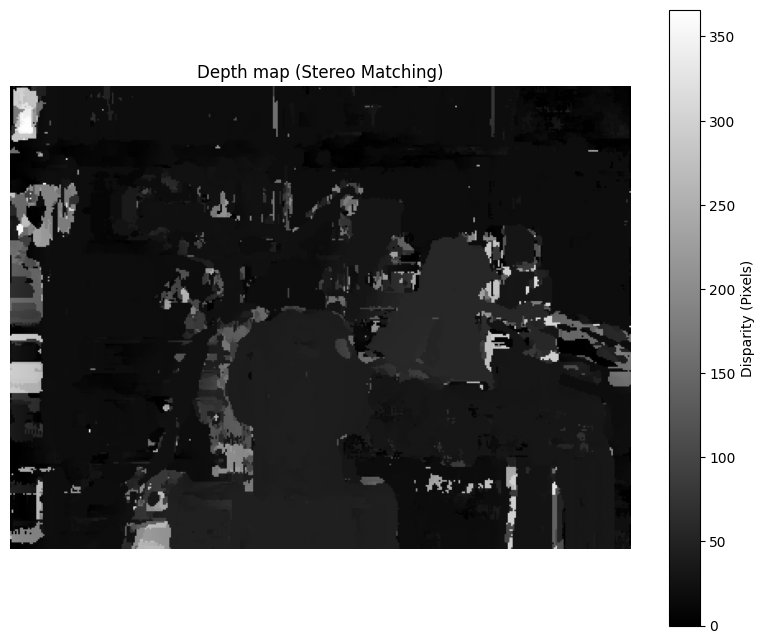

In [60]:
left = np.array(img_left_pos)
right = np.array(img_right_pos)

disparity = np.abs(left - right)

row = high - 7 + 1
column = wide - 7 + 1
disparity_map = disparity.reshape((row, column))

plt.figure(figsize=(10, 8))
plt.imshow(disparity_map, cmap='gray')
plt.colorbar(label='Disparity (Pixels)')
plt.title('Depth map (Stereo Matching)')
plt.axis('off')
plt.show()